**Objetivo:** Este examen tiene como objetivo evaluar la capacidad del estudiante para limpiar, explorar, implementar y evaluar modelos de regresión en un dataset de precios de casas. Utilizaremos el «House Prices Dataset» disponible en Kaggle. Los estudiantes deben demostrar habilidades prácticas en la manipulación de datos, creación de visualizaciones y modelado predictivo.

**Contexto y Descripción del Dataset**

El «House Prices Dataset» contiene datos sobre diversas características de casas residenciales en Ames, Iowa. La tarea es predecir el precio final de cada casa (variable objetivo) en función de sus características.

###1. **Limpieza de Datos:**
* **Identificación y eliminación de valores duplicados:** Asegúrate de que no haya registros duplicados que puedan sesgar los resultados del análisis.
* **Verificación y ajuste de tipos de datos:** Verifica que cada columna tenga el tipo de dato correcto (numérico o categórico) y ajusta si es necesario.
* **Corrección de inconsistencias en valores categóricos:** Revisa las categorías de las variables y unifica aquellos valores que puedan estar escritos de diferentes maneras pero que representen lo mismo.
* **Manejo de valores faltantes adecuadamente:** Identifica y maneja los valores faltantes utilizando técnicas apropiadas como la imputación de la mediana, media o moda, según corresponda.

In [42]:
# Carga de dato de los csv 'train' y 'test'
import pandas as pd
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [27]:
# Identificación y eliminación de valores duplicados
train_df_clean = train_df.drop_duplicates()
test_df_clean = test_df.drop_duplicates()

# Verificación de tipos de datos de 'train'
print(train_df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [29]:
# Verificación de tipos de datos de 'test'
print(test_df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [32]:
# Verificación de valores nulos en 'train'
print("Valores nulos en 'train':")
print(train_df_clean.isnull().sum().sum())

Valores nulos en 'train':
7829


In [33]:
# Verificación de valores nulos en 'test'
print("Valores nulos en 'test':")
print(test_df_clean.isnull().sum().sum())

Valores nulos en 'test':
7878


In [43]:
# Imputación de valores faltantes
# Identificar columnas numéricas y categóricas comunes en ambos conjuntos
common_numeric_columns = train_df_clean.select_dtypes(include=['float64', 'int64']).columns.intersection(test_df_clean.columns)
common_categorical_columns = train_df_clean.select_dtypes(include=['object']).columns.intersection(test_df_clean.columns)

# Imputar valores numéricos con la mediana del conjunto de entrenamiento
for col in common_numeric_columns:
    median = train_df_clean[col].median()
    train_df_clean[col] = train_df_clean[col].fillna(median)
    test_df_clean[col] = test_df_clean[col].fillna(median)

# Imputar valores categóricos con la moda del conjunto de entrenamiento
for col in common_categorical_columns:
    mode = train_df_clean[col].mode()[0]
    train_df_clean[col] = train_df_clean[col].fillna(mode)
    test_df_clean[col] = test_df_clean[col].fillna(mode)

In [45]:
# Conversión de columnas categóricas mal etiquetadas
potential_categorical_columns = ['MSSubClass', 'OverallCond', 'MoSold', 'YrSold']

for col in potential_categorical_columns:
    if col in train_df_clean.columns:
        train_df_clean[col] = train_df_clean[col].astype('category')
    if col in test_df_clean.columns:
        test_df_clean[col] = test_df_clean[col].astype('category')

###2. Exploración de Datos (EDA)
* Visualizaciones univariadas y multivariadas
* Estadísticas Descriptivas

* Visualizaciones univariadas

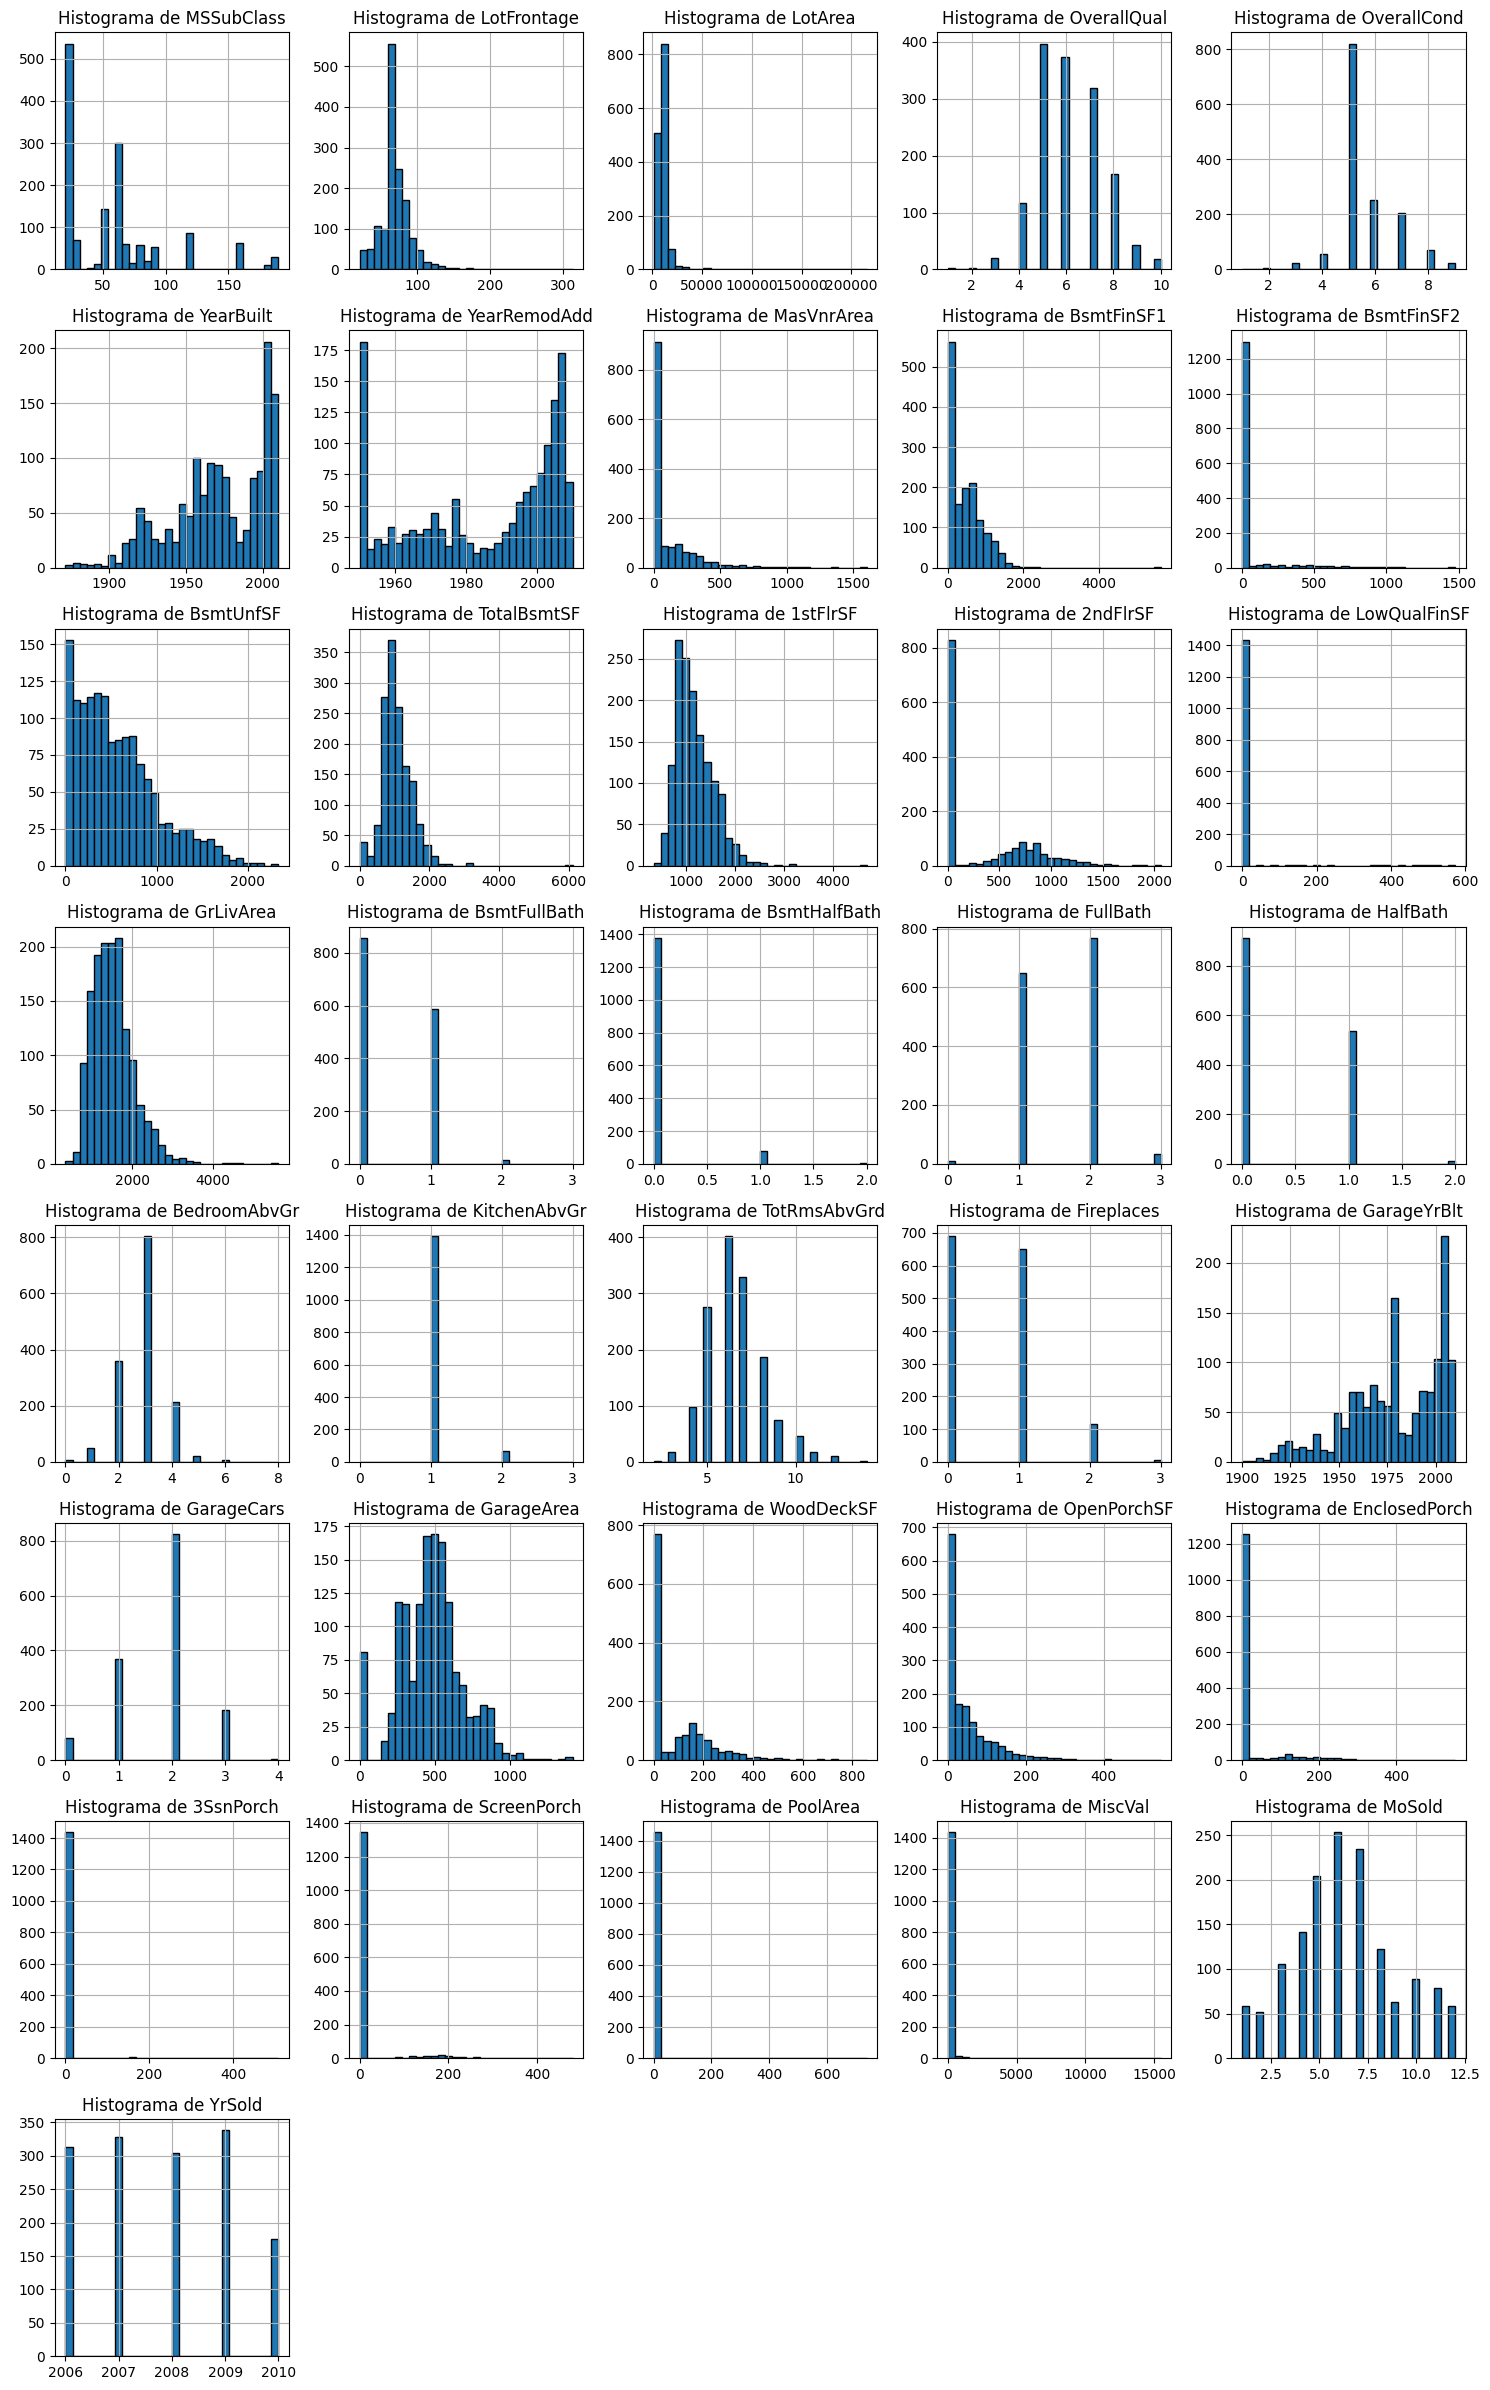

In [46]:
# Visualización de histogramas
import matplotlib.pyplot as plt

numeric_columns_filtered = [col for col in common_numeric_columns if col != 'Id']

num_plots = len(numeric_columns_filtered)
cols = 5
rows = (num_plots // cols) + (1 if num_plots % cols != 0 else 0)

plt.figure(figsize=(15, rows * 3))
for i, col in enumerate(numeric_columns_filtered, 1):
    plt.subplot(rows, cols, i)
    train_df_clean[col].hist(bins=30, edgecolor='black')
    plt.title(f'Histograma de {col}')
    plt.tight_layout()
plt.show()


* Visualización multivariada

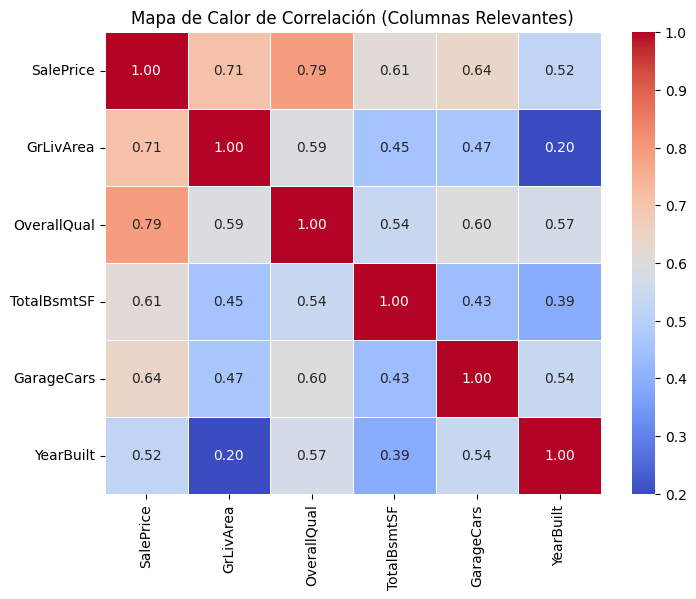

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar las columnas relevantes para la correlación
columns_of_interest = ['SalePrice', 'GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt']
data_of_interest = train_df_clean[columns_of_interest]

# Calcular la matriz de correlación
correlation_matrix = data_of_interest.corr()

# Generar el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlación (Columnas Relevantes)')
plt.show()


* Estadísticas descriptivas

In [48]:
# Estadísticas descriptivas
train_desc_stats = train_df_clean.describe()
train_desc_stats

,Id,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,69.863699,10516.828082,6.099315,1971.267808,1984.865753,103.117123,443.639726,46.549315,567.240411,...,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,180921.195890
std,421.610009,22.027677,9981.264932,1.382997,30.202904,20.645407,180.731373,456.098091,161.319273,441.866955,...,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,79442.502883
min,1.000000,21.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34900.000000
25%,365.750000,60.000000,7553.500000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,...,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,129975.000000
50%,730.500000,69.000000,9478.500000,6.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,...,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,163000.000000
75%,1095.250000,79.000000,11601.500000,7.000000,2000.000000,2004.000000,164.250000,712.250000,0.000000,808.000000,...,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,214000.000000
max,1460.000000,313.000000,215245.000000,10.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,...,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,755000.000000


###3. Implementación de modelos
* Modelos de Regresión: Implementa modelos de Linear Regression y KNN.
* Evaluación de Modelos: Evalúa los modelos utilizando métricas como MSE, RMSE, y R^2.
* Comparación de Rendimiento: Compara los resultados de ambos modelos y discute cuál es el más adecuado para este dataset.

* Preparación de datos de train_df_clean

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Características seleccionadas y objetivo
features = ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'GarageCars', 'MSSubClass', 'OverallCond']
target = 'SalePrice'

X_train = train_df_clean[features]
X_test = test_df_clean[features]
y_train = train_df_clean[target]

# Preprocesamiento: OneHotEncoder con handle_unknown='ignore'
categorical_features = ['MSSubClass', 'OverallCond']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)],
    remainder='passthrough'
)

# Transformar tanto train como test
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


* Regresión Lineal train_df_clean

In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Modelo de Regresión Lineal
lin_reg = LinearRegression()
lin_reg.fit(X_train_transformed, y_train)

y_pred_train = lin_reg.predict(X_train_transformed)

# Evaluación del modelo
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

# Resultados de Regresión Lineal
print("Resultados de Regresión Lineal:")
print(f"MSE: {mse_train:.2f}")
print(f"RMSE: {rmse_train:.2f}")
print(f"R^2: {r2_train:.2f}")

Resultados de Regresión Lineal:
MSE: 1325780414.54
RMSE: 36411.27
R^2: 0.79


In [60]:
# predicciones de regresión lineal con train
print("Predicciones de Regresión Lineal en el conjunto de entrenamiento:")
y_pred_train

Predicciones de Regresión Lineal en el conjunto de entrenamiento:


array([215728.89485116, 194452.55655375, 220469.61119687, ...,
       248752.98504991, 121022.44957829, 144491.73612986])

Regresión Lineal con test_df_clean

In [62]:
# Predicciones en el conjunto de prueba
y_pred_test = lin_reg.predict(X_test_transformed)

# Como no existe 'SalePrice' en el conjunto de prueba, solo mostramos las predicciones
print("Predicciones de Regresión Lineal en el conjunto de prueba:")
print(y_pred_test)

Predicciones de Regresión Lineal en el conjunto de prueba:
[112685.3906512  165269.42805281 169989.21211492 ... 160940.01141424
 110511.23954993 244256.48314143]


* KNN con train_df_clean

In [53]:
from sklearn.neighbors import KNeighborsRegressor

# Modelo KNN
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_transformed, y_train)

y_pred_train_knn = knn_reg.predict(X_train_transformed)

# Evaluación del modelo
mse_train_knn = mean_squared_error(y_train, y_pred_train_knn)
rmse_train_knn = np.sqrt(mse_train_knn)
r2_train_knn = r2_score(y_train, y_pred_train_knn)

# Resultados de KNN
print("Resultados de KNN:")
print(f"MSE: {mse_train_knn:.2f}")
print(f"RMSE: {rmse_train_knn:.2f}")
print(f"R^2: {r2_train_knn:.2f}")

Resultados de KNN:
MSE: 1271661784.66
RMSE: 35660.37
R^2: 0.80


In [63]:
# predicciones de knn con train
print("Predicciones de Regresión Lineal en el conjunto de entrenamiento:")
y_pred_train_knn

Predicciones de Regresión Lineal en el conjunto de entrenamiento:


array([197200., 157000., 209500., ..., 295540., 134045., 150300.])

* KNN con test_df_clean

In [72]:
# Predicciones en el conjunto de prueba
y_pred_test_knn = knn_reg.predict(X_test_transformed)

# Mostrar las predicciones
y_pred_test_knn

array([113380., 161180., 178700., ..., 137190., 144592., 242800.])

###Visualización comparativa

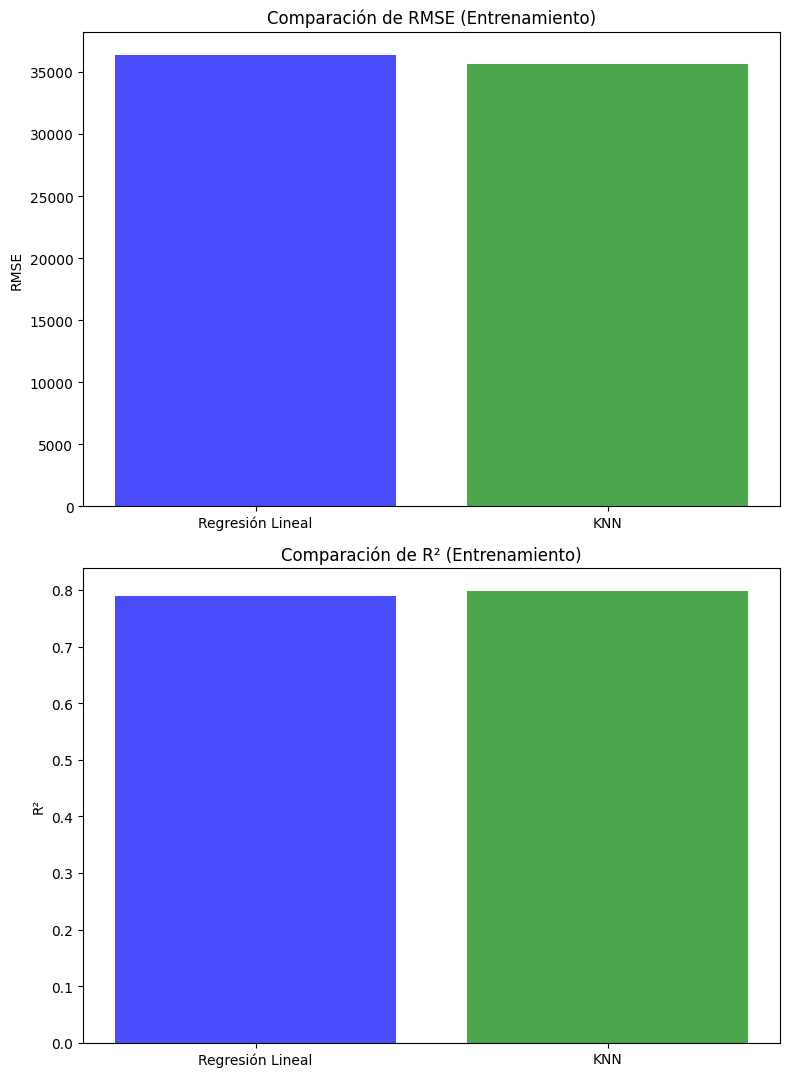

In [70]:
# Comparación de métricas: Regresión Lineal y KNN
# Comparación de métricas y predicciones para el conjunto de entrenamiento

# DataFrame con métricas
results_updated = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'KNN'],
    'MSE_Train': [mse_train, mse_train_knn],
    'RMSE_Train': [rmse_train, rmse_train_knn],
    'R²_Train': [r2_train, r2_train_knn]
})

# Gráficos comparativos
plt.figure(figsize=(8, 16))

# Comparación de RMSE
plt.subplot(3, 1, 1)
plt.bar(results_updated['Modelo'], results_updated['RMSE_Train'], color=['blue', 'green'], alpha=0.7)
plt.title('Comparación de RMSE (Entrenamiento)')
plt.ylabel('RMSE')

# Comparación de R²
plt.subplot(3, 1, 2)
plt.bar(results_updated['Modelo'], results_updated['R²_Train'], color=['blue', 'green'], alpha=0.7)
plt.title('Comparación de R² (Entrenamiento)')
plt.ylabel('R²')

plt.tight_layout()
plt.show()


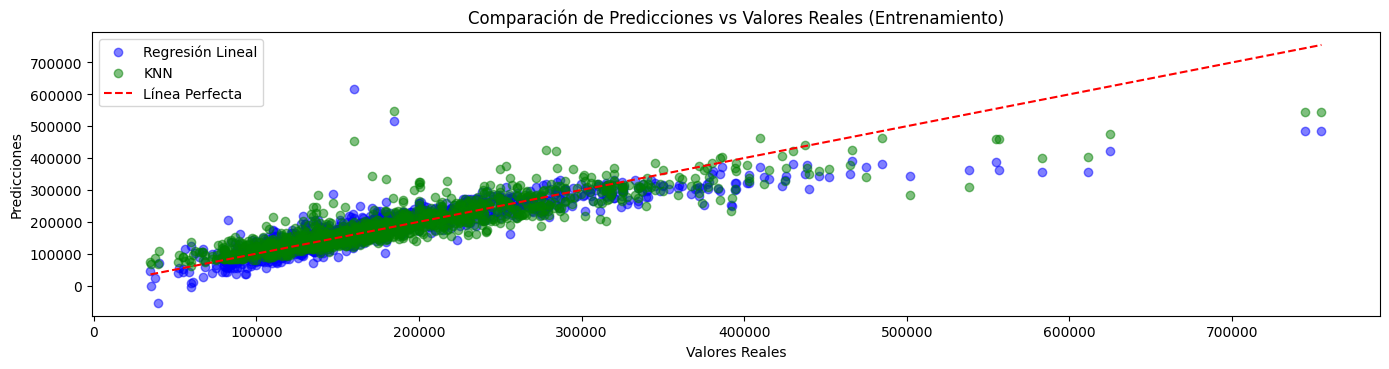

In [71]:
# Comparación de Predicciones (Regresión Lineal)
plt.figure(figsize=(14, 10))
plt.subplot(3, 1, 3)
plt.scatter(y_train, y_pred_train, color='blue', alpha=0.5, label='Regresión Lineal')
plt.scatter(y_train, y_pred_train_knn, color='green', alpha=0.5, label='KNN')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red', linestyle='--', label='Línea Perfecta')
plt.title('Comparación de Predicciones vs Valores Reales (Entrenamiento)')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.legend()

plt.tight_layout()
plt.show()

In [73]:
# Crear un DataFrame con las predicciones
output = pd.DataFrame({
    'Id': test_df_clean['Id'],
    'SalePrice_Pred_Linear': y_pred_test,
    'SalePrice_Pred_KNN': y_pred_test_knn
})

# Guardar las predicciones en un archivo CSV
output.to_csv('predicciones_test.csv', index=False)

In [74]:
# Crear un DataFrame con las predicciones para el conjunto de entrenamiento
output_train = pd.DataFrame({
    'Id': train_df_clean['Id'],  # Suponiendo que 'Id' existe en train_df_clean
    'SalePrice_Real': y_train,  # Valores reales de SalePrice
    'SalePrice_Pred_Linear': y_pred_train,  # Predicciones de Regresión Lineal
    'SalePrice_Pred_KNN': y_pred_train_knn  # Predicciones de KNN
})

# Guardar las predicciones en un archivo CSV
output_train.to_csv('predicciones_train.csv', index=False)
